In [1]:
import znnl as nl
import jax
import jax.numpy as np
import flax.linen as nn
import numpy as onp
from flax.training import train_state
import optax
from rich.progress import track
import matplotlib.pyplot as plt
from dataclasses import dataclass
import neural_tangents as nt
from sklearn.manifold import TSNE

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Network definition

In [3]:
class BulkNetwork(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=128)(x)
        return x
    
class Predictor(nn.Module):
    """A simple dense model."""
    
    def setup(self):
        self.bulk = BulkNetwork()
    
    @nn.compact
    def __call__(self, x):
        embedding_representation = self.bulk(x)
        x = nn.relu(embedding_representation)
        x = nn.Dense(features=10)(embedding_representation)
        return x
    

## Training functions

In [4]:
def create_train_state(module, rng, learning_rate):
    """Creates an initial TrainState."""

    params = module.init(rng, np.ones([1, 28, 28, 1]))['params']

    tx = optax.adam(learning_rate)

    return train_state.TrainState.create(
      apply_fn=module.apply, params=params, tx=tx,
    )

In [5]:
@jax.jit
def train_step(state, batch):
    """Train for a single step."""

    def loss_fn(params):
        logits = state.apply_fn({'params': params}, batch['inputs'])

        loss = np.linalg.norm(logits - batch["targets"], axis=-1).mean()

        return loss

    grad_fn = jax.grad(loss_fn)
    grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    return state

## Data loading

In [2]:
mnist_generator = nl.data.MNISTGenerator(ds_size=200)

In [3]:
mnist_generatort_generator.train_ds["targets"]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], dtype=float32)

## Model training

In [6]:
@dataclass
class Metrics:
    # Train metrics
    train_loss = []
    train_accuracy = []
    train_entropy = []
    train_trace = []
    train_embedding_reps = []
    train_outs = []
    
    # Test metrics
    test_loss = []
    test_accuracy = []
    test_entropy = []
    test_trace = []
    test_embedding_reps = []
    test_outs = []
    

In [8]:
n_epochs = 1000
batch_size = 32
learning_rate = 1e-4

model = Predictor()

# Seed the model state.
init_rng = jax.random.PRNGKey(onp.random.randint(76325426354))
state = create_train_state(model, init_rng, learning_rate)
del init_rng

# f(x, \theta)
def apply_fn(params, x):
    return model.apply({"params":params}, x, mutable=['batch_stats'])[0]

ntk_fn = get_ntk_function(apply_fn, batch_size=100)

metrics = Metrics()

for epoch in track(range(n_epochs), description="Working..."):
    
    # Perform training steps over batches
    train_ds_size = len(mnist_generator.train_ds["inputs"])
    steps_per_epoch = train_ds_size // batch_size

    # Prepare the shuffle.
    rng = jax.random.PRNGKey(onp.random.randint(764357264952))
    permutations = jax.random.permutation(rng, train_ds_size)
    permutations = np.array_split(permutations, steps_per_epoch)

    # Step over items in batch.
    for permutation in permutations:
        batch = {k: v[permutation, ...] for k, v in mnist_generator.train_ds.items()}
        state = train_step(state, batch)
            
    # Update test metrics
#     (
#         test_loss, test_accuracy, test_trace, test_entropy, test_embedding_reps, test_logits
#     ) = compute_metrics(state, mnist_generator.test_ds, ntk_fn=ntk_fn)
    
#     metrics.test_loss.append(test_loss)
#     metrics.test_accuracy.append(test_accuracy)
#     metrics.test_trace.append(test_trace)
#     metrics.test_entropy.append(test_entropy)
#     metrics.test_embedding_reps.append(test_embedding_reps)
#     metrics.test_outs.append(test_logits)

    # Update train metrics
    (
        train_loss, train_accuracy, train_trace, train_entropy, train_embedding_reps, train_logits
    ) = compute_metrics(state, mnist_generator.train_ds, ntk_fn=ntk_fn)
    
    metrics.train_loss.append(train_loss)
    metrics.train_accuracy.append(train_accuracy)
    metrics.train_trace.append(train_trace)
    metrics.train_entropy.append(train_entropy)
    metrics.train_embedding_reps.append(train_embedding_reps)
    metrics.train_outs.append(train_logits)


Output()

## Data Saving

In [13]:
metrics = np.load("data.npy", allow_pickle=True).item()

In [14]:
metrics

Metrics()

## Data analysis

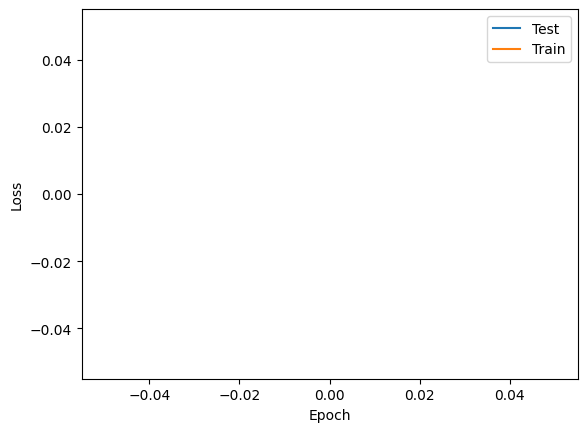

In [11]:
plt.plot(metrics.test_loss, label="Test")
plt.plot(metrics.train_loss, label="Train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

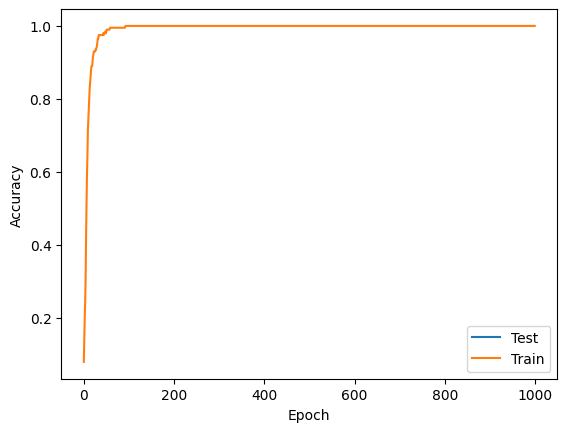

In [11]:
plt.plot(metrics.test_accuracy, label="Test")
plt.plot(metrics.train_accuracy, label="Train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

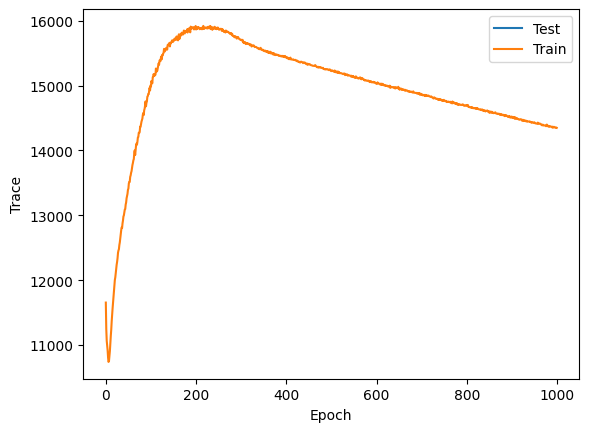

In [12]:
plt.plot(metrics.test_trace, label="Test")
plt.plot(metrics.train_trace, label="Train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Trace")
plt.show()

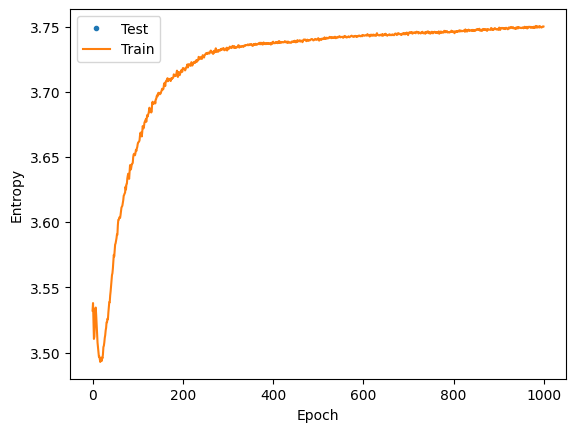

In [13]:
plt.plot(metrics.test_entropy, ".", label="Test")
plt.plot(metrics.train_entropy, label="Train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Entropy")
plt.show()

In [14]:
tsne_embedder = TSNE(
    n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=0
)
train_embedding_early = tsne_embedder.fit_transform(metrics.train_embedding_reps[0])
tsne_embedder = TSNE(
    n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=0
)
train_embedding_middle = tsne_embedder.fit_transform(metrics.train_embedding_reps[15])
tsne_embedder = TSNE(
    n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=0
)
train_embedding_late = tsne_embedder.fit_transform(metrics.train_embedding_reps[-1])

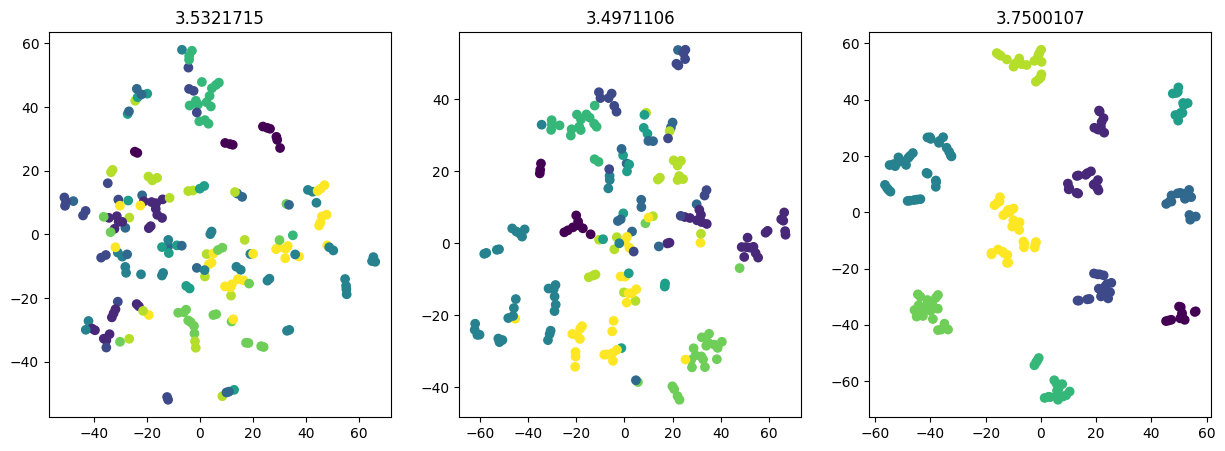

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(
    train_embedding_early[:, 0], 
    train_embedding_early[:, 1], 
    c=mnist_generator.train_ds["targets"].argmax(axis=-1), 
)
ax[0].set_title(metrics.train_entropy[0])

ax[1].scatter(
    train_embedding_middle[:, 0], 
    train_embedding_middle[:, 1], 
    c=mnist_generator.train_ds["targets"].argmax(axis=-1), 
)
ax[1].set_title(metrics.train_entropy[15])

ax[2].scatter(
    train_embedding_late[:, 0], 
    train_embedding_late[:, 1], 
    c=mnist_generator.train_ds["targets"].argmax(axis=-1), 
)
ax[2].set_title(metrics.train_entropy[-1])
# ax[2].colorbar()
plt.show()

## COM of classes

In [16]:
class_trajectories = {}
embeddings = np.array(metrics.train_embedding_reps)

for i in range(10):
    class_indices = np.where(mnist_generator.train_ds["targets"].argmax(axis=-1) == i)[0]
    
    class_trajectories[i] = np.take(embeddings, class_indices, axis=1)

In [17]:
class_centroids = {}

for item in class_trajectories:
    class_centroids[item] = np.mean(class_trajectories[item], axis=1)

In [41]:
rg = {}

for item in class_trajectories:
    rg[item] = np.sqrt(
        np.mean(
            np.linalg.norm(class_trajectories[item] - class_centroids[item][:, None, :], axis=-1), axis=1
        )
    )

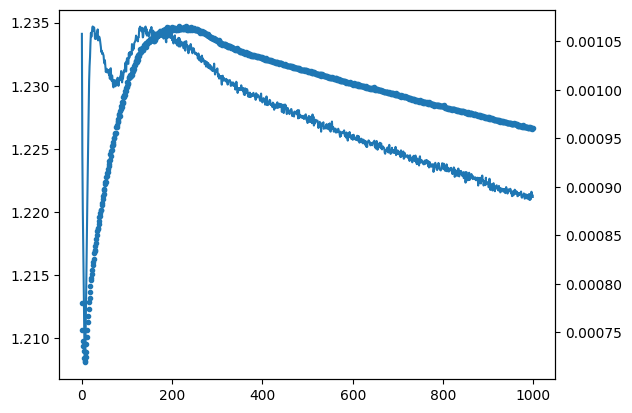

In [42]:
max_entropy = -1 * np.log(1/200)
fig, ax = plt.subplots()
ax1 = ax.twinx()

means = np.mean(np.array([item for item in rg.values()]), axis=0)
# for item in rg:
#     ax.plot(rg[item], label=item)
ax.plot(means)
    
ax1.plot(np.array(metrics.train_trace) / np.array(metrics.train_trace).sum(), ".")
# ax1.plot(np.array(metrics.train_entropy) / max_entropy , "--")
# plt.legend()
plt.show()

## Fluctations

In [20]:
class_trajectories = {}
embeddings = np.array(metrics.train_embedding_reps)

for i in range(10):
    class_indices = np.where(mnist_generator.train_ds["targets"].argmax(axis=-1) == i)[0]
    
    class_trajectories[i] = np.take(embeddings, class_indices, axis=1)

In [21]:
class_centroids = {}

for item in class_trajectories:
    class_centroids[item] = np.mean(class_trajectories[item], axis=1)

In [22]:
class_differences = {}

for item in class_trajectories:
    class_differences[item] = np.mean(
        np.linalg.norm(
            np.diff(
                class_trajectories[item] - class_centroids[item][:, None, :], axis=0
            ),
            axis=-1
        ), 
        axis=1
    )

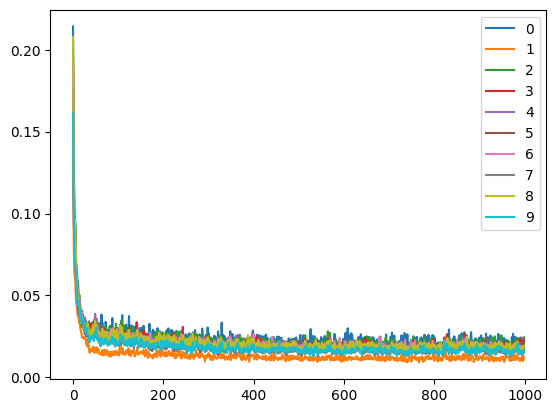

In [23]:
for item in class_differences:
    plt.plot(class_differences[item], label=item)
    
plt.legend()
plt.show()

## MSD calculation

In [43]:
train_reps = np.array(metrics.train_outs)
embedding_reps = np.array(metrics.train_embedding_reps)

In [44]:
msd = (train_reps - train_reps[0]) ** 2
msd_other = (embedding_reps - embedding_reps[0]) ** 2

In [45]:
msd = np.mean(msd, axis=-1)
msd_other = np.mean(msd_other, axis=-1)

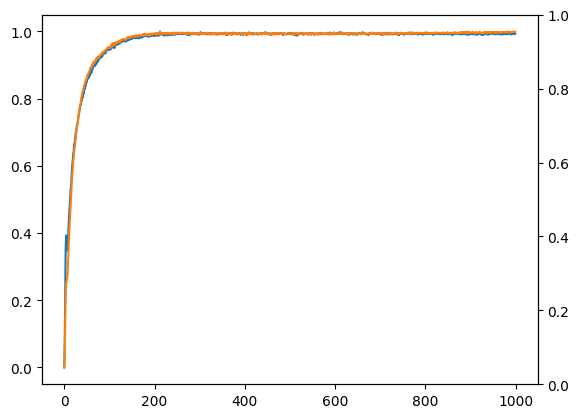

In [46]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(np.mean(msd, axis=1) / max(np.mean(msd, axis=1)))
ax.plot(np.mean(msd_other, axis=1) / max(np.mean(msd_other, axis=1)))

# ax2.plot(metrics.train_trace)
plt.show()

## Global Expansion

In [47]:
global_centroid = np.mean(np.array(metrics.train_embedding_reps), axis=1)

In [48]:
rg = np.sqrt(
    np.mean(
        np.linalg.norm(
            np.array(metrics.train_embedding_reps) - global_centroid[:, None, :], axis=-1
        ),
        axis=1
    )
)

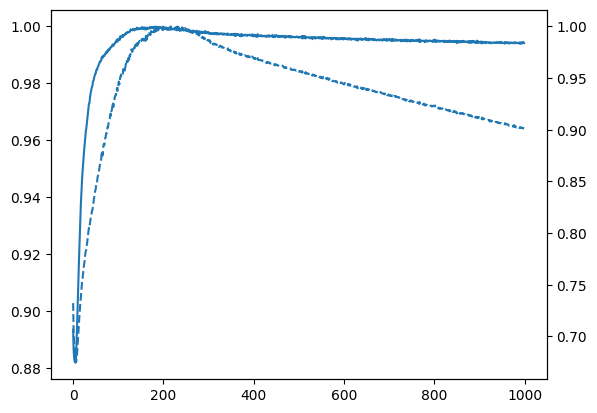

In [53]:
fig, ax = plt.subplots()
ax1 = ax.twinx()
ax1.plot(np.array(metrics.train_trace) / np.array(metrics.train_trace).max() , '--')
ax.plot(rg / rg.max())
plt.show()

## Variance of all particles motions

In [31]:
embeddings = np.array(metrics.train_embedding_reps)
embeddings_diff = np.diff(embeddings, axis=0)
embeddings_std_mean = np.std(embeddings_diff, axis=1).mean(axis=-1)

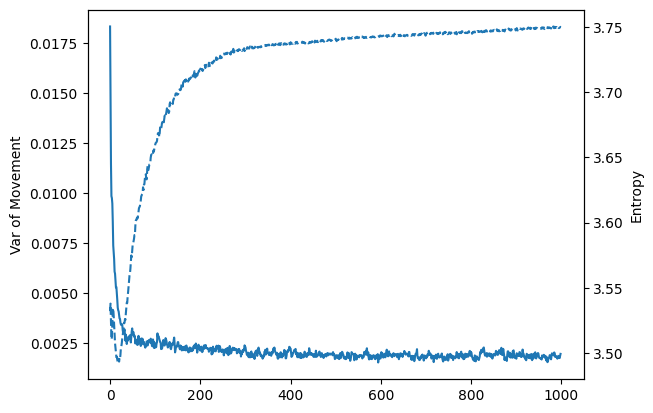

In [32]:
fig, ax = plt.subplots()
ax1 = ax.twinx()
ax1.plot(np.array(metrics.train_entropy), '--')
ax1.set_ylabel("Entropy")
ax.set_ylabel("Var of Movement")
ax.plot(embeddings_std_mean)
plt.show()

## Measure of Local Order

In [33]:
class_trajectories = {}
embeddings = np.array(metrics.train_embedding_reps)

for i in range(10):
    class_indices = np.where(mnist_generator.train_ds["targets"].argmax(axis=-1) == i)[0]
    
    class_trajectories[i] = np.take(embeddings, class_indices, axis=1)

In [34]:
class_centroids = {}

for item in class_trajectories:
    class_centroids[item] = np.mean(class_trajectories[item], axis=1)

In [35]:
class_com_trajectories = {}

for item in class_trajectories:
    class_com_trajectories[item] = class_trajectories[item] - class_centroids[item][:, None, :]

### RDF Computation

In [50]:
class_distances = {}

for item in class_com_trajectories:
    trajectories = class_com_trajectories[item]
    
    
    class_distances[item] = np.linalg.norm(
        (trajectories[:, :, None, :] - trajectories[:, None, :, :]), axis=-1, ord=1
    )
    

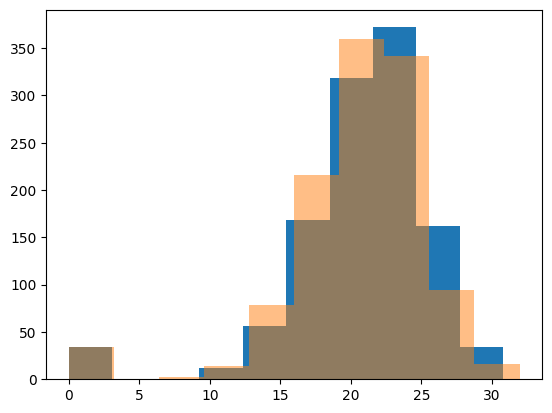

In [51]:
plt.hist(class_distances[4][0].flatten())
plt.hist(class_distances[4][10].flatten(), alpha=0.5)
plt.show()

In [38]:
window_size = 8

class_com_std = {}

for item in class_com_trajectories:
    class_com_std[item] = []
    for t in range(class_com_trajectories[0].shape[0]-window_size):
        std_window = np.std(np.abs(class_com_trajectories[item][t:t+window_size, ...]), axis=0)
#         std_window /= np.std(class_com_trajectories[item][t+window_size//2], axis=0)[None, None, :]
        class_com_std[item].append(std_window)
    class_com_std[item] = np.array(class_com_std[item]).mean(axis=-1).mean(axis=-1)

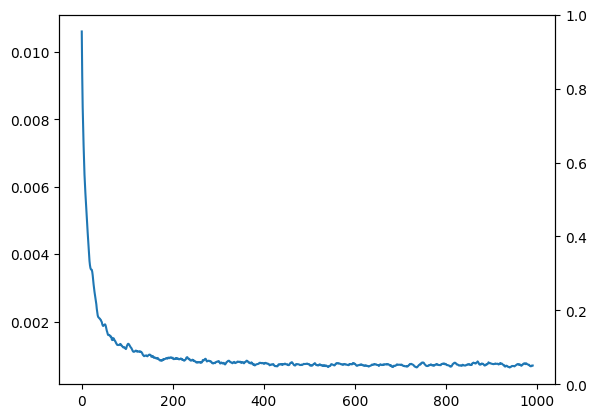

In [39]:
fig, ax = plt.subplots()
ax1 = ax.twinx()

# plt.plot(onp.gradient(means))
ax.plot(class_com_std[1])